# Momentum Engineering (Notebook)

This notebook mirrors `momentum.py` and adds visual checks at each step.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
BASE_DIR = Path(".")
valid_bookings_df = pd.read_parquet(BASE_DIR / "valid_bookings.parquet")
valid_bookings_df.head()

,has_promptpay,has_cc,has_shopee_pay,has_special_request,medium,created_at,prepared,refund,adjusted,ack,...,adult,end_time,start_time,active,revenue_dollars,booking_date,day_of_week_index,day_of_week,is_outlier,outlier_reason
3,NaN,NaN,NaN,NaN,<NA>,2023-08-13T05:47:00.000000,False,False,False,True,...,1,19:00:00,19:00:00,True,149.93,2025-05-13,1,Tuesday,False,
4,NaN,1.0,0.0,0.0,Web,2023-08-24T12:38:03,False,False,False,True,...,2,19:00:00,19:00:00,True,302.25,2024-06-17,0,Monday,False,
8,NaN,1.0,0.0,0.0,Web,2023-08-26T13:45:03,False,False,False,True,...,3,19:00:00,19:00:00,True,590.36,2024-06-06,3,Thursday,False,
10,NaN,NaN,NaN,1.0,Web,2023-09-22T03:57:13,False,False,False,True,...,2,18:00:00,17:00:00,True,199.60,2024-03-28,3,Thursday,False,
11,NaN,1.0,0.0,0.0,iOS,2023-09-25T03:09:57,False,False,False,True,...,7,18:00:00,18:00:00,True,1057.87,2025-12-18,3,Thursday,False,


In [2]:
#remove outliers from restaurant_id based on google sheet 
outlier_ids = [4503, 4502, 933, 837]
valid_bookings_df = valid_bookings_df[~valid_bookings_df['restaurant_id'].isin(outlier_ids)]
valid_bookings_df.shape


(452349, 29)

In [3]:
BASE_PATH = Path.cwd().parent.parent
PARQUET_PATH = BASE_PATH / "data" / "mv_dataset_parquet"
restaurants = pd.read_parquet(PARQUET_PATH / "restaurants.parquet")
restaurants.shape

(2474, 3)

In [4]:
valid_bookings_df = valid_bookings_df.merge(restaurants, on="restaurant_id", how="left")
valid_bookings_df.head()

,has_promptpay,has_cc,has_shopee_pay,has_special_request,medium,created_at,prepared,refund,adjusted,ack,...,start_time,active,revenue_dollars,booking_date,day_of_week_index,day_of_week,is_outlier,outlier_reason,name,days_in_advance
0,NaN,NaN,NaN,1.0,Web,2023-09-22T03:57:13,False,False,False,True,...,17:00:00,True,199.6,2024-03-28,3,Thursday,False,,Vantage Point QSNCC,180.0
1,1.0,NaN,0.0,1.0,Web,2023-10-16T13:37:18,False,False,False,True,...,19:00:00,True,232.8,2024-02-10,5,Saturday,False,,Place Bangkok,90.0
2,NaN,NaN,0.0,0.0,iOS,2023-10-24T14:44:53,False,False,False,True,...,17:00:00,True,1119.8,2024-01-20,5,Saturday,False,,Chatrium Hotel Riverside Bangkok Staycation,90.0
3,1.0,NaN,0.0,0.0,Web,2023-10-25T09:38:08,False,False,False,True,...,14:00:00,True,180.0,2024-03-30,5,Saturday,False,,<NA>,NaN
4,NaN,NaN,0.0,1.0,iOS,2023-10-28T04:42:45,False,False,False,True,...,18:00:00,True,199.6,2024-01-21,6,Sunday,False,,Vantage Point QSNCC,180.0


In [5]:
#retrieve places api data from csv
CSV_PATH = BASE_PATH / "_1_eda" / "places_api_new_results.csv"

# Load the CSV
google_restaurants_df = pd.read_csv(CSV_PATH)
google_restaurants_df.shape

(2392, 12)

In [6]:
valid_bookings_df = valid_bookings_df.merge(google_restaurants_df, left_on='name', right_on='input_string', how='left')
valid_bookings_df.head()

,has_promptpay,has_cc,has_shopee_pay,has_special_request,medium,created_at,prepared,refund,adjusted,ack,...,official_name,city,country,formatted_address,rating,website,error,Cuisine,Cuisine_confidence,raw_types
0,NaN,NaN,NaN,1.0,Web,2023-09-22T03:57:13,False,False,False,True,...,Vantage Point,NaN,Thailand,ชั้น 2 เลขที่ 60 Queen Sirikit National Conven...,4.2,https://www.facebook.com/VantagePointRestaurante,API key not valid. Please pass a valid API key.,General,0.15,"buffet_restaurant,restaurant,food,point_of_int..."
1,1.0,NaN,0.0,1.0,Web,2023-10-16T13:37:18,False,False,False,True,...,place.bangkok,NaN,Thailand,"73/3 ซอย อินทามระ 4 Khwaeng Samsen Nai, Khet P...",4.4,https://www.facebook.com/placebangkok/,API key not valid. Please pass a valid API key.,Italian,0.70,"italian_restaurant,restaurant,point_of_interes..."
2,NaN,NaN,0.0,0.0,iOS,2023-10-24T14:44:53,False,False,False,True,...,Chatrium Hotel Riverside Bangkok,NaN,Thailand,"28 ถ. เจริญกรุง Khwaeng Wat Phraya Krai, Khet ...",4.6,https://www.chatrium.com/chatriumriversidebang...,API key not valid. Please pass a valid API key.,NaN,0.20,"hotel,lodging,point_of_interest,establishment"
3,1.0,NaN,0.0,0.0,Web,2023-10-25T09:38:08,False,False,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,0.0,1.0,iOS,2023-10-28T04:42:45,False,False,False,True,...,Vantage Point,NaN,Thailand,ชั้น 2 เลขที่ 60 Queen Sirikit National Conven...,4.2,https://www.facebook.com/VantagePointRestaurante,API key not valid. Please pass a valid API key.,General,0.15,"buffet_restaurant,restaurant,food,point_of_int..."


In [7]:
# 1. Create a deep copy to avoid SettingWithCopy warnings
clean_bookings_df = valid_bookings_df.copy()

# 2. Count before for your records
initial_count = len(clean_bookings_df)
print (f"Initial records: {initial_count}")

# 3. Drop records where user_id_masked is an empty string or NaN
clean_bookings_df = clean_bookings_df[
    (clean_bookings_df['user_id_masked'] != "") & 
    (clean_bookings_df['user_id_masked'].notna())
]

# 4. Verification
removed_count = initial_count - len(clean_bookings_df)
print(f"Removed {removed_count} records with empty or null user_id_masked.")
print(f"Remaining records: {len(clean_bookings_df)}")

Initial records: 452349
Removed 135856 records with empty or null user_id_masked.
Remaining records: 316493


In [8]:
# The 'Gold Standard' for identifying these specific system duplicates
logic_columns = [
    'user_id_masked', 
    'restaurant_id', 
    'booking_date', 
    'start_time', 
    'end_time', 
    'active'
]

# Identify the duplicates
duplicate_mask = clean_bookings_df.duplicated(subset=logic_columns, keep=False)
duplicates_only = clean_bookings_df[duplicate_mask].sort_values(by=['user_id_masked', 'id'])

# Count them
unique_duplicate_events = duplicates_only.groupby(logic_columns).ngroups

print(f"Identified {unique_duplicate_events} events that have redundant system entries.")

Identified 2720 events that have redundant system entries.


In [9]:
# Select only the identifying columns to verify they are identical
verification_cols = ['id', 'user_id_masked', 'restaurant_id', 'booking_date', 'start_time', 'end_time', 'revenue_dollars', 'active']

# View the top 20 duplicates with these specific columns
duplicates_only[verification_cols].head(20)

,id,user_id_masked,restaurant_id,booking_date,start_time,end_time,revenue_dollars,active
279293,7485531,10004982607977776954,894,2025-05-11,13:00:00,15:00:00,226.40,True
279295,7485538,10004982607977776954,894,2025-05-11,13:00:00,15:00:00,136.00,True
163625,6392572,1002398865849034957,2592,2024-11-13,18:00:00,18:00:00,1099.00,True
163630,6392601,1002398865849034957,2592,2024-11-13,18:00:00,18:00:00,769.30,True
327266,7755687,10038524973759102977,4385,2025-07-26,18:00:00,20:00:00,76.56,True
327276,7755712,10038524973759102977,4385,2025-07-26,18:00:00,20:00:00,76.56,True
81665,5264161,10049410200564458075,3279,2024-07-07,12:00:00,12:00:00,99.90,True
81667,5264174,10049410200564458075,3279,2024-07-07,12:00:00,12:00:00,99.90,True
81668,5264186,10049410200564458075,3279,2024-07-07,12:00:00,12:00:00,99.90,True
236,3991557,10050903249521646579,2001,2024-02-04,12:00:00,14:00:00,1505.00,True


In [10]:
# We sort by ID descending so the highest ID appears first for each group
final_bookings_df = clean_bookings_df.sort_values('id', ascending=False).drop_duplicates(
    subset=logic_columns, 
    keep='first'
)

In [11]:
# Calculate the IDs that were removed (the "old_transaction_ids")
all_ids = set(clean_bookings_df['id'])
kept_ids = set(final_bookings_df['id'])
old_transaction_ids = list(all_ids - kept_ids)

print(f"Original Records: {len(clean_bookings_df)}")
print(f"Cleaned Records: {len(final_bookings_df)}")
print(f"Total 'Old' IDs identified for deletion: {len(old_transaction_ids)}")

Original Records: 316493
Cleaned Records: 313276
Total 'Old' IDs identified for deletion: 3149


## 0) Guardrails / required cols

In [12]:
import requests

# 1. Setup Currency Reference
country_to_currency = {
    'Thailand': 'THB', 'Singapore': 'SGD', 'Malaysia': 'MYR',
    'United States': 'USD', 'Japan': 'JPY', 'Hong Kong': 'HKD',
    'United Kingdom': 'GBP', 'Australia': 'AUD', 'Vietnam': 'VND',
    'Indonesia': 'IDR', 'India': 'INR', 'France': 'EUR',
    'Italy': 'EUR', 'Netherlands': 'EUR'
}

# 2. Fetch Live Rates
def get_live_rates(base_currency='USD'):
    url = f"https://open.er-api.com/v6/latest/{base_currency}"
    try:
        response = requests.get(url)
        data = response.json()
        if data['result'] == 'success':
            return data['rates']
    except Exception:
        pass
    # Fallback to approx rates if API is down
    return {'THB': 35.5, 'SGD': 1.34, 'MYR': 4.7, 'JPY': 150.0, 'USD': 1.0, 'EUR': 0.92}

exchange_rates = get_live_rates('USD')

# 3. Clean and Validate DataFrame
# Note: Ensure 'country' and 'revenue_dollars' exist for the conversion to work
required_cols = ["restaurant_id", "booking_date", "id", "revenue_dollars", "country"]
missing = [c for c in required_cols if c not in final_bookings_df.columns]
if missing:
    raise ValueError(f"final_bookings_df missing required columns: {missing}")

# Handle Dates and NaNs
final_bookings_df["booking_date"] = pd.to_datetime(final_bookings_df["booking_date"], errors="coerce")
final_bookings_df = final_bookings_df.dropna(subset=["booking_date", "restaurant_id"])

# 4. Apply Currency Conversion
def perform_conversion(row):
    country = row['country']
    amount = row['revenue_dollars']
    currency_code = country_to_currency.get(country)
    
    if currency_code and pd.notnull(amount):
        rate = exchange_rates.get(currency_code)
        if rate:
            # API gives 1 USD = X Local. So we divide Local / Rate to get USD.
            return amount / rate
    return amount

final_bookings_df["revenue_usd"] = final_bookings_df.apply(perform_conversion, axis=1)

# 5. Handle Guest Logic
if "total_guests" not in final_bookings_df.columns:
    if "adult" in final_bookings_df.columns and "kids" in final_bookings_df.columns:
        final_bookings_df["total_guests"] = (
            final_bookings_df["adult"].fillna(0) + final_bookings_df["kids"].fillna(0)
        )
    else:
        final_bookings_df["total_guests"] = np.nan

print(f"Final Shape: {final_bookings_df.shape}")

Final Shape: (313276, 45)


In [13]:
final_bookings_df.head(10)

,has_promptpay,has_cc,has_shopee_pay,has_special_request,medium,created_at,prepared,refund,adjusted,ack,...,country,formatted_address,rating,website,error,Cuisine,Cuisine_confidence,raw_types,revenue_usd,total_guests
452348,NaN,NaN,0.0,0.0,Android,2026-01-07T04:50:49,False,False,False,True,...,Thailand,"B Floor, Banyan Tree Bangkok, 21/100 S Sathon ...",4.6,https://www.banyantree.com/thailand/bangkok/di...,API key not valid. Please pass a valid API key.,Thai,0.70,"buffet_restaurant,thai_restaurant,asian_restau...",2.528883,1
452346,NaN,NaN,0.0,0.0,iOS,2026-01-07T04:50:12,False,False,False,True,...,Thailand,"Siphya, 2 ถ. เจริญกรุง แขวงบางรัก เขตบางรัก กร...",4.5,https://www.marriott.com/en-us/dining/restaura...,API key not valid. Please pass a valid API key.,Italian,0.70,"italian_restaurant,restaurant,food,point_of_in...",4.399433,2
452343,NaN,NaN,0.0,0.0,Web,2026-01-07T04:47:17,False,False,False,True,...,Thailand,"Kimpton Maa-Lai Bangkok, Soi Ton Son, Khwaeng ...",4.7,https://bit.ly/GGStockRoom,API key not valid. Please pass a valid API key.,General,0.15,"restaurant,food,point_of_interest,establishment",6.266818,2
452340,1.0,NaN,0.0,0.0,iOS,2026-01-07T04:46:48,False,False,False,True,...,Thailand,"55 ถนน ศรีนครินทร์ Khwaeng Nong Bon, Khet Praw...",4.7,http://www.boontongkeethailand.com/home/out-ou...,API key not valid. Please pass a valid API key.,General,0.15,"restaurant,food,point_of_interest,establishment",4.367782,4
452338,1.0,NaN,0.0,0.0,Android,2026-01-07T04:45:14,False,False,False,True,...,Thailand,"Queen Sirikit National Convention Center, 60 T...",4.1,https://foa.co.th/,API key not valid. Please pass a valid API key.,Chinese,0.70,"chinese_restaurant,restaurant,point_of_interes...",11.156835,4
452336,NaN,1.0,0.0,0.0,iOS,2026-01-07T04:43:41,False,False,False,True,...,Thailand,"1 Rachadaphisek Road, Fortune Town, แขวงดินแดง...",4.4,NaN,API key not valid. Please pass a valid API key.,Chinese,0.70,"chinese_restaurant,restaurant,food,point_of_in...",3.034659,1
452334,NaN,NaN,0.0,0.0,iOS,2026-01-07T04:41:50,False,False,False,True,...,Thailand,"166, 1-5 ถนน รัชดา 10 Khwaeng Huai Khwang, Khe...",4.4,https://www.facebook.com/kuangseafood2,API key not valid. Please pass a valid API key.,Seafood,0.70,"seafood_restaurant,restaurant,point_of_interes...",28.865342,8
452332,NaN,1.0,0.0,0.0,iOS,2026-01-07T04:38:50,False,False,False,True,...,Thailand,เลขที่ 9/8-9 Kagonoya ชั้น 7 ห้อง 730 Thanon R...,3.3,https://m.facebook.com/kagonoyathailand,API key not valid. Please pass a valid API key.,Japanese,0.70,"japanese_restaurant,restaurant,food,point_of_i...",12.296256,5
452331,NaN,NaN,0.0,0.0,Android,2026-01-07T04:37:46,False,False,False,True,...,Thailand,"24th floor, Centara Grand and Bangkok Conventi...",4.3,https://www.ventisibangkok.com/,API key not valid. Please pass a valid API key.,General,0.15,"restaurant,point_of_interest,food,establishment",25.067271,8
452330,NaN,NaN,0.0,0.0,Web,2026-01-07T04:35:34,False,False,False,True,...,Thailand,"Ground Level Chatrium 728 Thanon Phetchaburi, ...",4.7,https://www.chatrium.com/grandbangkok/savio,API key not valid. Please pass a valid API key.,General,0.15,"restaurant,point_of_interest,food,establishment",7.121384,3


In [14]:
final_bookings_df.to_parquet("valid_bookings_with_currency_and_google_restaurants_without_duplicates.parquet")

## 1) Monthly aggregation

In [15]:
final_bookings_df["year_month"] = final_bookings_df["booking_date"].dt.to_period("M").dt.to_timestamp()

# Filter out advance bookings beyond Feb 2026
cutoff_month = pd.Timestamp("2026-01-31")
final_bookings_df = final_bookings_df[final_bookings_df["year_month"] <= cutoff_month].copy()

restaurants_agg = (
    final_bookings_df
    .groupby(["name", "year_month"], as_index=False)
    .agg(
        monthly_bookings=("id", "count"),
        monthly_revenue=("revenue_usd", "sum"),
        avg_revenue_per_booking=("revenue_usd", "mean"),
        avg_guests=("total_guests", "mean"),
        active_days=("booking_date", lambda x: x.dt.date.nunique()),
    )
)

#do note monthly_revenue here refers to the usd denominated revenue, please confirm based on above steps 
restaurants_agg["monthly_bookings"] = restaurants_agg["monthly_bookings"].fillna(0).astype(int)
restaurants_agg["monthly_revenue"] = restaurants_agg["monthly_revenue"].fillna(0.0)
restaurants_agg["avg_revenue_per_booking"] = restaurants_agg["avg_revenue_per_booking"].replace([np.inf, -np.inf], np.nan)
restaurants_agg["avg_revenue_per_booking"] = restaurants_agg["avg_revenue_per_booking"].fillna(0.0)

restaurants_agg = restaurants_agg.sort_values(["name", "year_month"]).reset_index(drop=True)
restaurants_agg.head()

,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days
0,Charoen Rung Rueang International Buffet MS S...,2024-08-01,7,101.231262,14.461609,2.285714,6
1,Charoen Rung Rueang International Buffet MS S...,2024-10-01,32,689.637972,21.551187,3.406250,19
2,Charoen Rung Rueang International Buffet MS S...,2024-11-01,21,398.598094,18.980862,3.000000,17
3,Charoen Rung Rueang International Buffet MS S...,2024-12-01,21,493.502402,23.500114,3.714286,11
4,Charoen Rung Rueang International Buffet MS S...,2025-01-01,20,335.328555,16.766428,2.650000,14


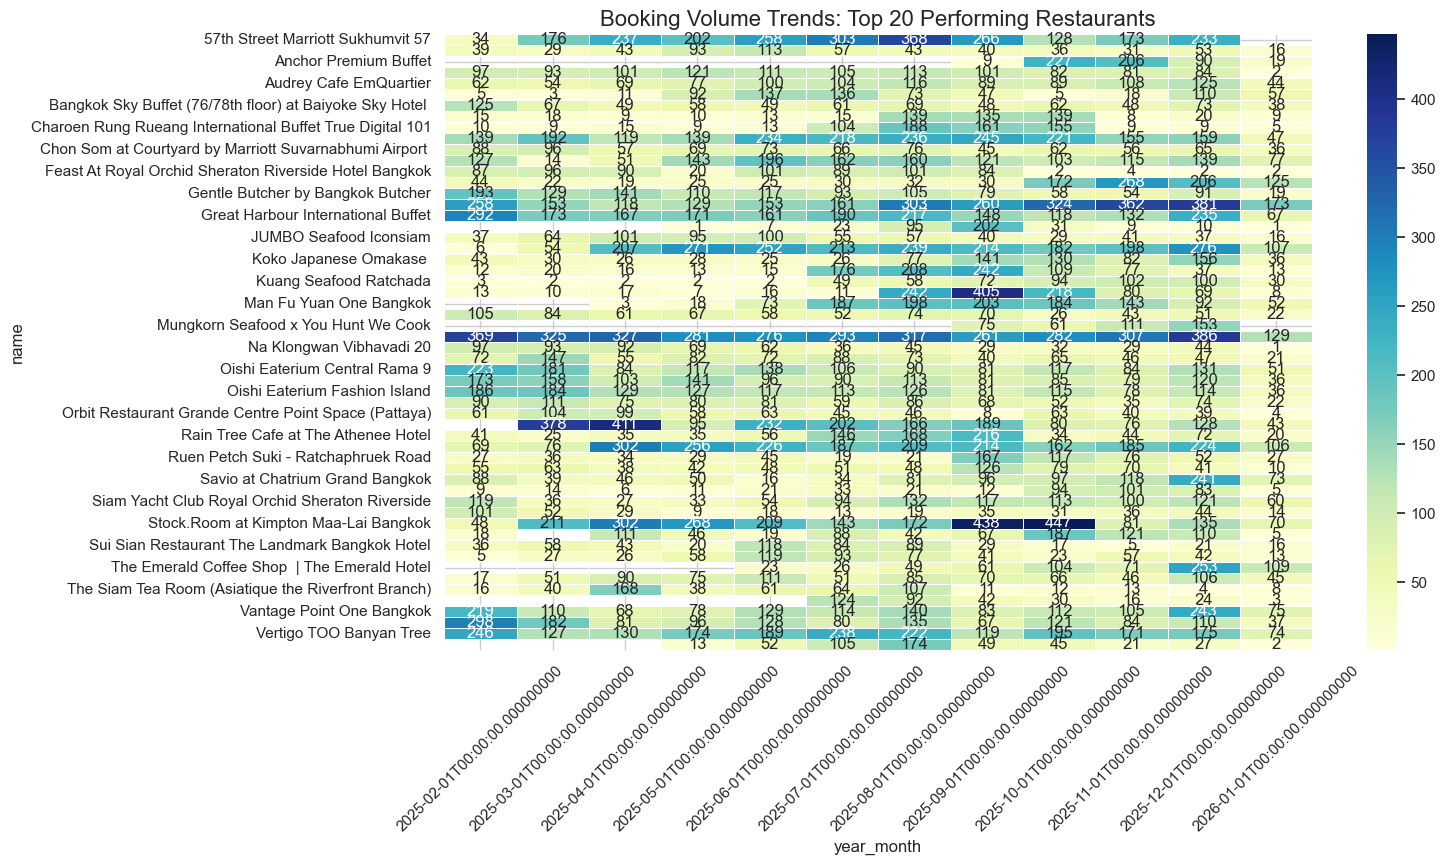

In [16]:
start_date = cutoff_month - pd.DateOffset(months=12)

# 2. Filter for the last 12 months
last_12_months_df = restaurants_agg[
    (restaurants_agg["year_month"] >= start_date) & 
    (restaurants_agg["year_month"] <= cutoff_month)
].copy()

# 3. Extract top 20 for each month
top_20_per_month = (
    last_12_months_df.sort_values(["year_month", "monthly_bookings"], ascending=[True, False])
    .groupby("year_month")
    .head(20)
)

# 1. Get the list of restaurant names that were ever in a Top 20 in the last 12 months
top_restaurants = top_20_per_month['name'].unique()

# 2. Pivot the data: Rows = Restaurants, Cols = Months, Values = Bookings
heatmap_data = last_12_months_df[last_12_months_df['name'].isin(top_restaurants)].pivot(
    index='name', 
    columns='year_month',
    values='monthly_bookings'
)

# 3. Plot
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
plt.title("Booking Volume Trends: Top 20 Performing Restaurants", fontsize=16)
plt.xticks(rotation=45)
plt.show()


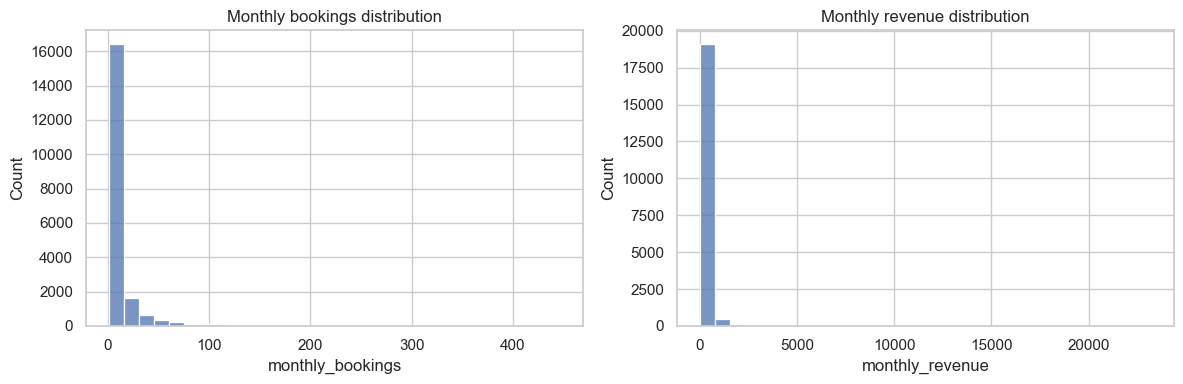

In [17]:
# Plot bookings and revenue distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(restaurants_agg["monthly_bookings"], bins=30, ax=axes[0])
axes[0].set_title("Monthly bookings distribution")

sns.histplot(restaurants_agg["monthly_revenue"], bins=30, ax=axes[1])
axes[1].set_title("Monthly revenue distribution")
plt.tight_layout()

## 2) Minimum history filter

In [18]:
restaurants_agg

,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days
0,Charoen Rung Rueang International Buffet MS S...,2024-08-01,7,101.231262,14.461609,2.285714,6
1,Charoen Rung Rueang International Buffet MS S...,2024-10-01,32,689.637972,21.551187,3.406250,19
2,Charoen Rung Rueang International Buffet MS S...,2024-11-01,21,398.598094,18.980862,3.000000,17
3,Charoen Rung Rueang International Buffet MS S...,2024-12-01,21,493.502402,23.500114,3.714286,11
4,Charoen Rung Rueang International Buffet MS S...,2025-01-01,20,335.328555,16.766428,2.650000,14
...,...,...,...,...,...,...,...
19877,中国好味道 China Taste,2025-07-01,1,5.281574,5.281574,3.000000,1
19878,中国好味道 China Taste,2025-10-01,1,5.202979,5.202979,3.000000,1
19879,馥苑 Fu Yuan Teochew Dining,2025-11-01,1,19.648712,19.648712,4.000000,1
19880,馥苑 Fu Yuan Teochew Dining,2025-12-01,1,16.701406,16.701406,4.000000,1


In [19]:
# MIN_MONTHS = 3
# hist = restaurants_agg.groupby("name")["year_month"].nunique()
# keep_ids = hist[hist >= MIN_MONTHS].index
# restaurants_agg = restaurants_agg[restaurants_agg["name"].isin(keep_ids)].copy()
# restaurants_agg.shape

# Don't think this is necessary

In [20]:
restaurants_agg


,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days
0,Charoen Rung Rueang International Buffet MS S...,2024-08-01,7,101.231262,14.461609,2.285714,6
1,Charoen Rung Rueang International Buffet MS S...,2024-10-01,32,689.637972,21.551187,3.406250,19
2,Charoen Rung Rueang International Buffet MS S...,2024-11-01,21,398.598094,18.980862,3.000000,17
3,Charoen Rung Rueang International Buffet MS S...,2024-12-01,21,493.502402,23.500114,3.714286,11
4,Charoen Rung Rueang International Buffet MS S...,2025-01-01,20,335.328555,16.766428,2.650000,14
...,...,...,...,...,...,...,...
19877,中国好味道 China Taste,2025-07-01,1,5.281574,5.281574,3.000000,1
19878,中国好味道 China Taste,2025-10-01,1,5.202979,5.202979,3.000000,1
19879,馥苑 Fu Yuan Teochew Dining,2025-11-01,1,19.648712,19.648712,4.000000,1
19880,馥苑 Fu Yuan Teochew Dining,2025-12-01,1,16.701406,16.701406,4.000000,1


## 3) Winsorise extremes

In [21]:
# def winsorise_series(s: pd.Series, lower_q=0.01, upper_q=0.99) -> pd.Series:
#     lo = s.quantile(lower_q)
#     hi = s.quantile(upper_q)
#     return s.clip(lower=lo, upper=hi)

# for col in ["monthly_bookings", "monthly_revenue", "avg_revenue_per_booking"]:
#     restaurants_agg[col] = winsorise_series(restaurants_agg[col])

# restaurants_agg[["monthly_bookings","monthly_revenue","avg_revenue_per_booking"]].describe().T

# Don't think this is necessary either

## 4) Growth + rolling growth

                                                    name  booking_growth_pct
0       Charoen Rung Rueang International Buffet MS S...                 NaN
1       Charoen Rung Rueang International Buffet MS S...            3.571429
2       Charoen Rung Rueang International Buffet MS S...           -0.343750
3       Charoen Rung Rueang International Buffet MS S...            0.000000
4       Charoen Rung Rueang International Buffet MS S...           -0.047619
...                                                  ...                 ...
19877                                  中国好味道 China Taste                 NaN
19878                                  中国好味道 China Taste            0.000000
19879                          馥苑 Fu Yuan Teochew Dining                 NaN
19880                          馥苑 Fu Yuan Teochew Dining            0.000000
19881                          馥苑 Fu Yuan Teochew Dining            0.000000

[19882 rows x 2 columns]
                                                  

C:\Users\foogu\AppData\Local\Temp\ipykernel_18476\2234198780.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


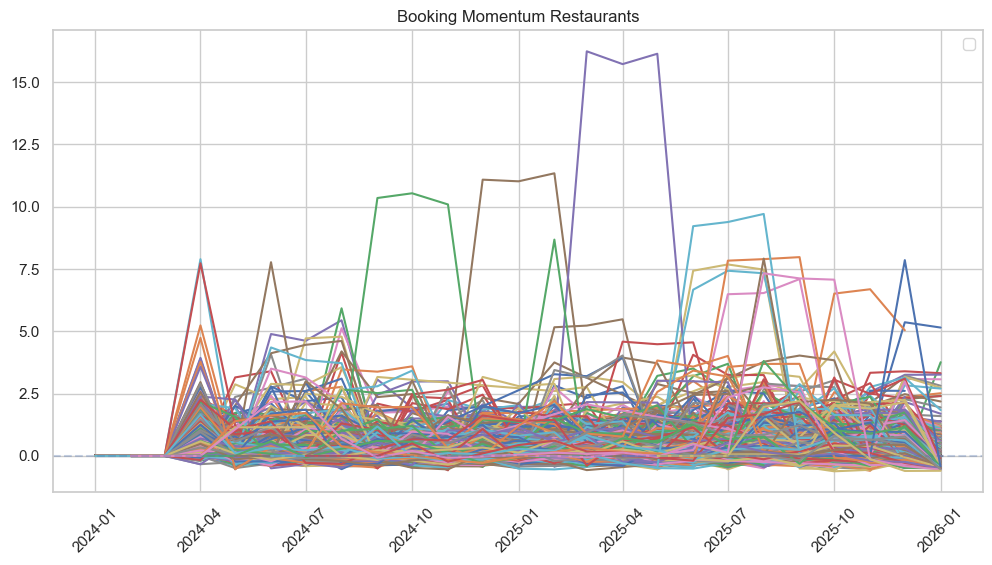

In [22]:
restaurants_agg["booking_growth_pct"] = (
    restaurants_agg.groupby("name")["monthly_bookings"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
)

print(restaurants_agg[["name","booking_growth_pct"]])

restaurants_agg["revenue_growth_pct"] = (
    restaurants_agg.groupby("name")["monthly_revenue"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
)

print(restaurants_agg[["name","revenue_growth_pct"]])

ROLL = 3
restaurants_agg["booking_growth_rolling"] = (
    restaurants_agg.groupby("name")["booking_growth_pct"]
    .rolling(ROLL, min_periods=ROLL)
    .mean()
    .reset_index(level=0, drop=True)
)

print(restaurants_agg[["name","booking_growth_rolling"]])


restaurants_agg["revenue_growth_rolling"] = (
    restaurants_agg.groupby("name")["revenue_growth_pct"]
    .rolling(ROLL, min_periods=ROLL)
    .mean()
    .reset_index(level=0, drop=True)
)
print(restaurants_agg[["name","revenue_growth_rolling"]])

restaurants_agg["booking_growth_rolling"] = restaurants_agg["booking_growth_rolling"].fillna(0.0)
restaurants_agg["revenue_growth_rolling"] = restaurants_agg["revenue_growth_rolling"].fillna(0.0)

restaurants_agg[["booking_growth_rolling","revenue_growth_rolling"]].describe().T

import matplotlib.pyplot as plt


latest = restaurants_agg.sort_values("year_month").groupby("name").tail(1)

top_movers = (
    latest
    .sort_values("booking_growth_rolling", ascending=False)["name"]
)

plt.figure(figsize=(12,6))

for name in top_movers:
    df = restaurants_agg[restaurants_agg["name"] == name]
    plt.plot(df["year_month"], df["booking_growth_rolling"])

plt.axhline(0, linestyle="--", alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.title("Booking Momentum Restaurants")
plt.show()



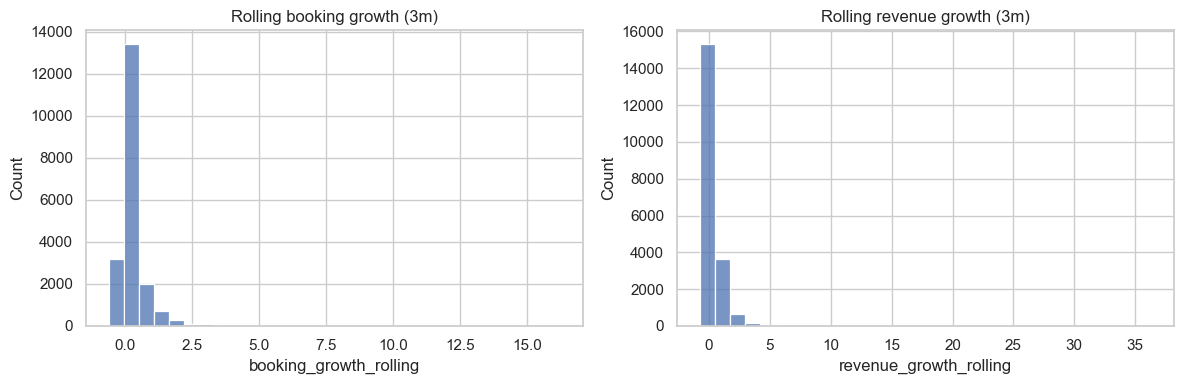

In [23]:
# Growth distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(restaurants_agg["booking_growth_rolling"], bins=30, ax=axes[0])
axes[0].set_title("Rolling booking growth (3m)")

sns.histplot(restaurants_agg["revenue_growth_rolling"], bins=30, ax=axes[1])
axes[1].set_title("Rolling revenue growth (3m)")
plt.tight_layout()

C:\Users\foogu\AppData\Local\Temp\ipykernel_18476\3281014347.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\foogu\AppData\Local\Temp\ipykernel_18476\3281014347.py:26: UserWarning: Glyph 24565 (\N{CJK UNIFIED IDEOGRAPH-5FF5}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\foogu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24565 (\N{CJK UNIFIED IDEOGRAPH-5FF5}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


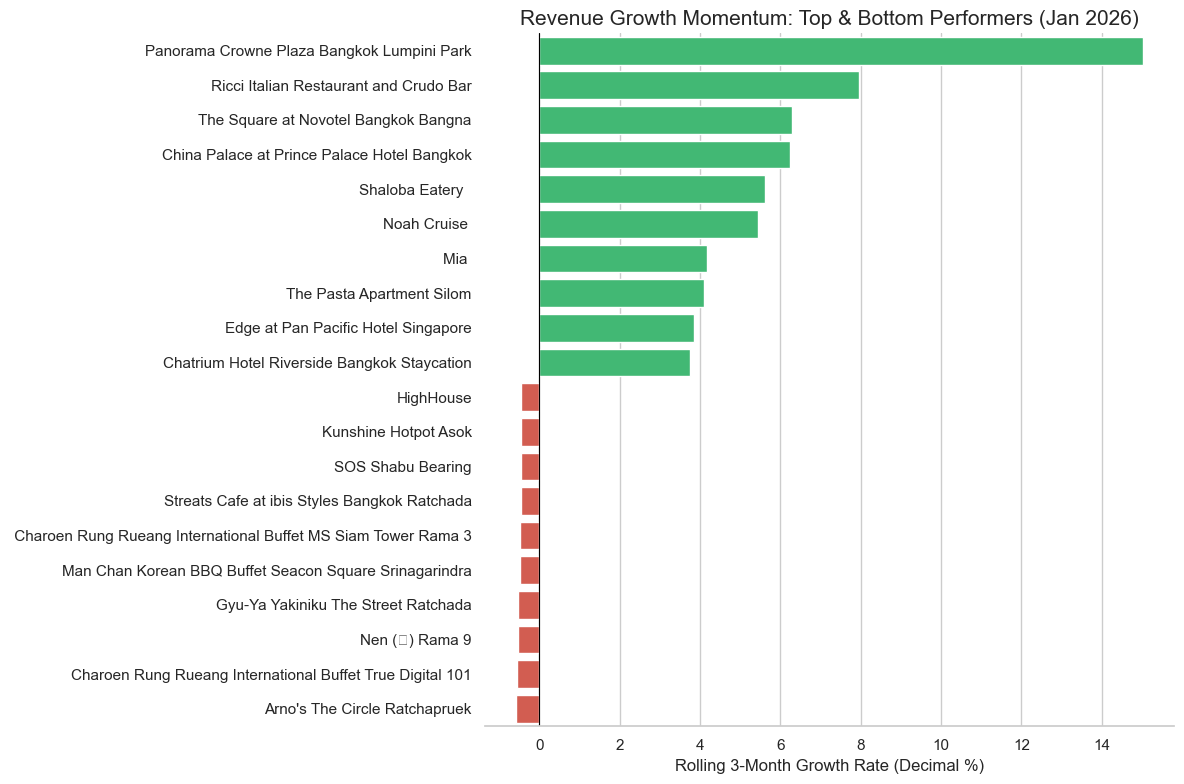

In [24]:
# 1. Get the most recent month's data (Jan 2026)
latest_month_label = restaurants_agg['year_month'].max()
latest_growth = restaurants_agg[restaurants_agg['year_month'] == latest_month_label].copy()

# 2. Identify Top 10 and Bottom 10 by Revenue Growth
top_growth = latest_growth.nlargest(10, "revenue_growth_rolling")
bottom_growth = latest_growth.nsmallest(10, "revenue_growth_rolling")
leaderboard = pd.concat([top_growth, bottom_growth]).sort_values("revenue_growth_rolling", ascending=False)

# 3. Plot
plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in leaderboard['revenue_growth_rolling']]

sns.barplot(
    data=leaderboard,
    x="revenue_growth_rolling",
    y="name",
    palette=colors
)

plt.axvline(0, color='black', linewidth=0.8) # Zero line for reference
plt.title(f"Revenue Growth Momentum: Top & Bottom Performers ({latest_month_label.strftime('%b %Y')})", fontsize=15)
plt.xlabel("Rolling 3-Month Growth Rate (Decimal %)", fontsize=12)
plt.ylabel("")
sns.despine(left=True)
plt.tight_layout()
plt.show()

(233, 7)
Shape after correct merge: (233, 9)


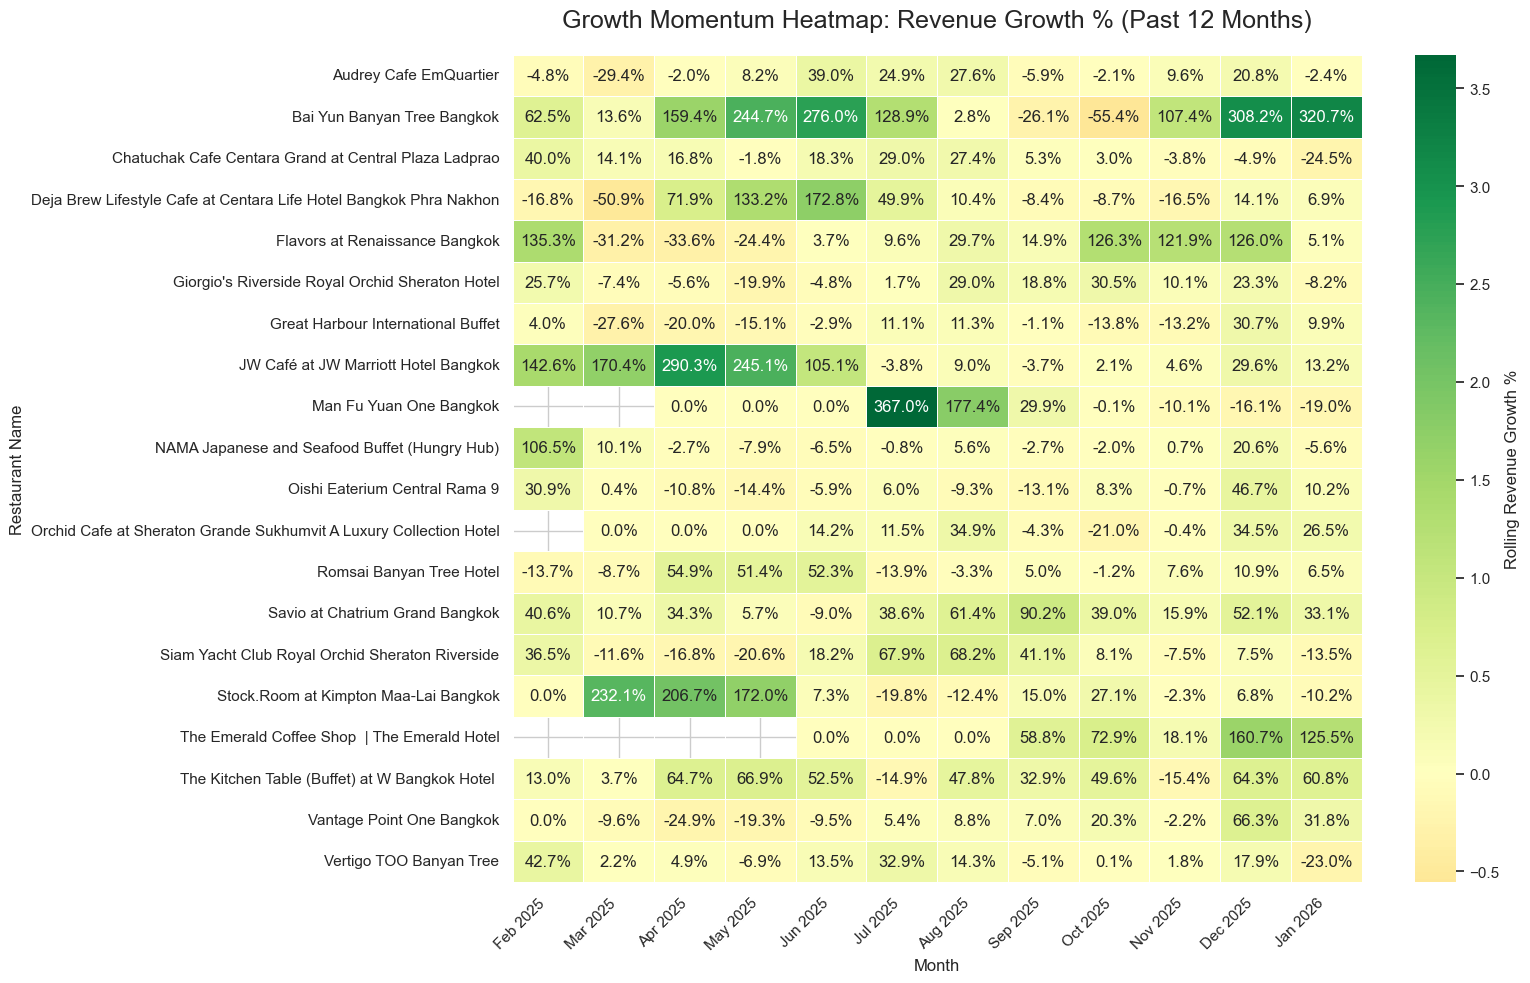

In [ ]:
# 1. Filter for the Top 20 restaurants (by latest month volume) 

top_20_names = latest_growth.nlargest(20, "monthly_bookings")["name"].tolist()
growth_trend_df = last_12_months_df[last_12_months_df['name'].isin(top_20_names)]
print(growth_trend_df.shape)


# 2. Pivot the rolling growth data -- growth trend_df does not have the revenue_growth_rolling column yet, so we need to merge it
growth_trend_df = growth_trend_df.merge(
    restaurants_agg[['name', 'year_month', 'booking_growth_rolling', 'revenue_growth_rolling']],
    on=['name', 'year_month'],
    how='left'
)

print(f"Shape after correct merge: {growth_trend_df.shape}")

growth_heatmap = growth_trend_df.pivot(
    index='name', 
    columns='year_month', 
    values='revenue_growth_rolling'
)


# 3. Sort chronologically and format labels
growth_heatmap.columns = [d.strftime('%b %Y') for d in growth_heatmap.columns]

# 4. Plot using a Diverging Color Map (RdYlGn: Red-Yellow-Green)
plt.figure(figsize=(16, 10))
sns.heatmap(
    growth_heatmap, 
    annot=True, 
    fmt=".1%", 
    cmap="RdYlGn", 
    center=0, 
    linewidths=.5,
    cbar_kws={'label': 'Rolling Revenue Growth %'}
)

plt.title("Growth Momentum Heatmap: Revenue Growth % (Past 12 Months)", fontsize=18, pad=20)
plt.ylabel("Restaurant Name", fontsize=12)
plt.xlabel("Month", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

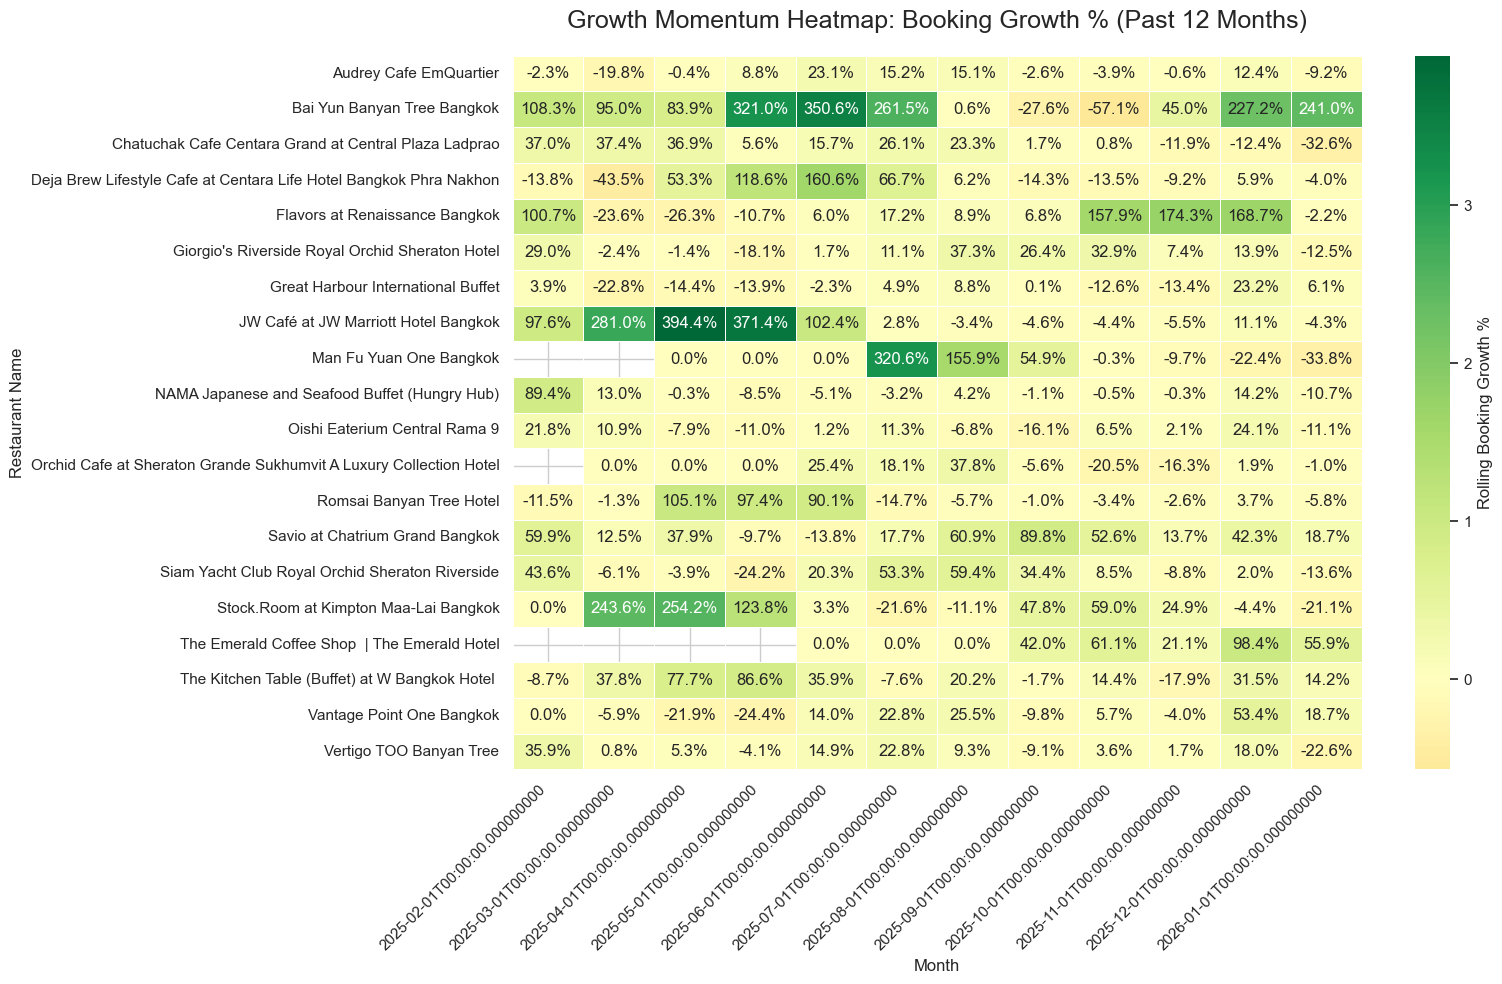

In [37]:
booking_growth_heatmap = growth_trend_df.pivot(
    index='name', 
    columns='year_month', 
    values='booking_growth_rolling'
)

# 4. Plot using a Diverging Color Map (RdYlGn: Red-Yellow-Green)
plt.figure(figsize=(16, 10))
sns.heatmap(
    booking_growth_heatmap, 
    annot=True, 
    fmt=".1%", 
    cmap="RdYlGn", 
    center=0, 
    linewidths=.5,
    cbar_kws={'label': 'Rolling Booking Growth %'}
)

plt.title("Growth Momentum Heatmap: Booking Growth % (Past 12 Months)", fontsize=18, pad=20)
plt.ylabel("Restaurant Name", fontsize=12)
plt.xlabel("Month", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5) Standardize into comparable scores

In [40]:
def pct_rank(s: pd.Series) -> pd.Series:
    return s.rank(pct=True, method="average")

restaurants_agg["perf_bookings_rank"] = pct_rank(restaurants_agg["monthly_bookings"])
restaurants_agg["perf_spend_rank"] = pct_rank(restaurants_agg["avg_revenue_per_booking"])
restaurants_agg["performance_score"] = (restaurants_agg["perf_bookings_rank"] + restaurants_agg["perf_spend_rank"]) / 2

restaurants_agg["growth_bookings_rank"] = pct_rank(restaurants_agg["booking_growth_rolling"])
restaurants_agg["growth_revenue_rank"] = pct_rank(restaurants_agg["revenue_growth_rolling"])
restaurants_agg["growth_score"] = (restaurants_agg["growth_bookings_rank"] + restaurants_agg["growth_revenue_rank"]) / 2

restaurants_agg[["performance_score","growth_score"]].describe().T

,count,mean,std,min,25%,50%,75%,max
performance_score,19882.0,0.500025,0.216709,0.068001,0.334156,0.511499,0.667796,0.977869
growth_score,19882.0,0.500025,0.273805,0.000327,0.350996,0.380313,0.743685,0.999950


In [41]:
restaurants_agg

,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days,booking_growth_pct,revenue_growth_pct,booking_growth_rolling,revenue_growth_rolling,perf_bookings_rank,perf_spend_rank,performance_score,growth_bookings_rank,growth_revenue_rank,growth_score
0,Charoen Rung Rueang International Buffet MS S...,2024-08-01,7,101.231262,14.461609,2.285714,6,NaN,NaN,0.000000,0.000000,0.681697,0.831053,0.756375,0.361483,0.340509,0.350996
1,Charoen Rung Rueang International Buffet MS S...,2024-10-01,32,689.637972,21.551187,3.406250,19,3.571429,5.812500,0.000000,0.000000,0.912459,0.904386,0.908422,0.361483,0.340509,0.350996
2,Charoen Rung Rueang International Buffet MS S...,2024-11-01,21,398.598094,18.980862,3.000000,17,-0.343750,-0.422018,0.000000,0.000000,0.867066,0.887587,0.877326,0.361483,0.340509,0.350996
3,Charoen Rung Rueang International Buffet MS S...,2024-12-01,21,493.502402,23.500114,3.714286,11,0.000000,0.238095,1.075893,1.876192,0.867066,0.913389,0.890227,0.938588,0.958706,0.948647
4,Charoen Rung Rueang International Buffet MS S...,2025-01-01,20,335.328555,16.766428,2.650000,14,-0.047619,-0.320513,-0.130456,-0.168145,0.860603,0.866261,0.863432,0.114174,0.083996,0.099085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19877,中国好味道 China Taste,2025-07-01,1,5.281574,5.281574,3.000000,1,NaN,NaN,0.000000,0.000000,0.135952,0.391485,0.263718,0.361483,0.340509,0.350996
19878,中国好味道 China Taste,2025-10-01,1,5.202979,5.202979,3.000000,1,0.000000,-0.014881,0.000000,0.000000,0.135952,0.379891,0.257922,0.361483,0.340509,0.350996
19879,馥苑 Fu Yuan Teochew Dining,2025-11-01,1,19.648712,19.648712,4.000000,1,NaN,NaN,0.000000,0.000000,0.135952,0.892767,0.514360,0.361483,0.340509,0.350996
19880,馥苑 Fu Yuan Teochew Dining,2025-12-01,1,16.701406,16.701406,4.000000,1,0.000000,-0.150000,0.000000,0.000000,0.135952,0.865280,0.500616,0.361483,0.340509,0.350996


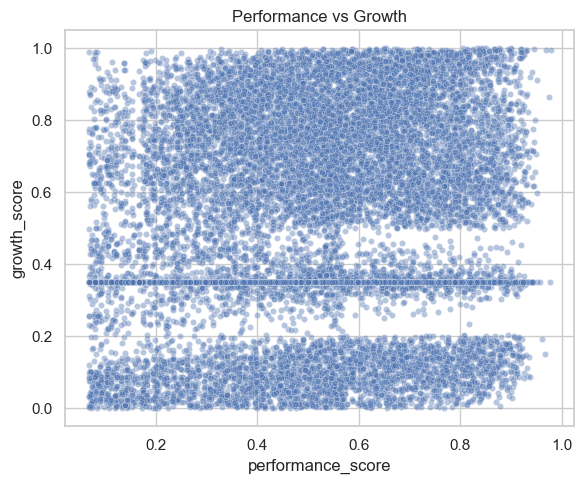

In [42]:
# Performance vs Growth scatter
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=restaurants_agg,
    x="performance_score",
    y="growth_score",
    alpha=0.4,
    s=20
)
plt.title("Performance vs Growth")
plt.tight_layout()

## 6) Composite momentum + segmentation

In [43]:
# i think we may have to weigh the performance and growth scores (based on industry standards)
perf_weight = 0.4
restaurants_agg["momentum_score"] = perf_weight * restaurants_agg["performance_score"] + (1 - perf_weight) * restaurants_agg["growth_score"]

perf_cut = restaurants_agg["performance_score"].median()
grow_cut = restaurants_agg["growth_score"].median()

restaurants_agg["momentum_segment"] = np.select(
    [
        (restaurants_agg["performance_score"] >= perf_cut) & (restaurants_agg["growth_score"] >= grow_cut),
        (restaurants_agg["performance_score"] <  perf_cut) & (restaurants_agg["growth_score"] >= grow_cut),
        (restaurants_agg["performance_score"] >= perf_cut) & (restaurants_agg["growth_score"] <  grow_cut),
        (restaurants_agg["performance_score"] <  perf_cut) & (restaurants_agg["growth_score"] <  grow_cut),
    ],
    [
        "Rising Stars",
        "Emerging Opportunities",
        "Established Players",
        "Needs Attention",
    ],
    default="Unclassified"
)

restaurants_agg[["momentum_score","momentum_segment"]].head()

,momentum_score,momentum_segment
0,0.513148,Established Players
1,0.573966,Established Players
2,0.561528,Established Players
3,0.925279,Rising Stars
4,0.404823,Established Players


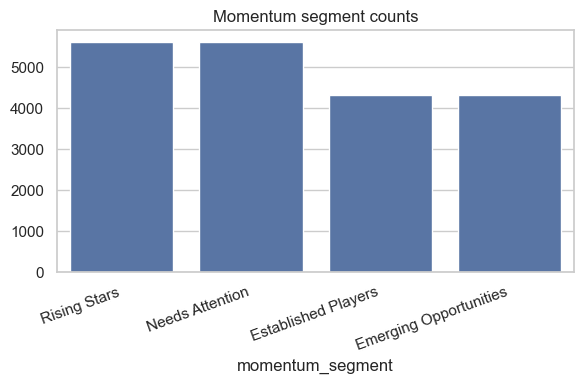

In [44]:
# Segment counts
plt.figure(figsize=(6, 4))
segment_counts = restaurants_agg["momentum_segment"].value_counts()
sns.barplot(x=segment_counts.index, y=segment_counts.values)
plt.title("Momentum segment counts")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

In [45]:
restaurants_agg.to_parquet("restaurants_agg_performance.parquet")

## 7) Latest-month prioritised list

In [46]:
latest_month = restaurants_agg["year_month"].max()
priority_latest = (
    restaurants_agg[restaurants_agg["year_month"] == latest_month]
    .sort_values("momentum_score", ascending=False)
    .reset_index(drop=True)
)

print("Latest month:", latest_month.date())
print(priority_latest["momentum_segment"].value_counts(dropna=False))
priority_latest.head(10)

Latest month: 2026-01-01
momentum_segment
Needs Attention           255
Emerging Opportunities    212
Rising Stars              184
Established Players       145
Name: count, dtype: int64


,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days,booking_growth_pct,revenue_growth_pct,booking_growth_rolling,revenue_growth_rolling,perf_bookings_rank,perf_spend_rank,performance_score,growth_bookings_rank,growth_revenue_rank,growth_score,momentum_score,momentum_segment
0,Bai Yun Banyan Tree Bangkok,2026-01-01,57,723.057835,12.685225,4.087719,19,-0.481818,-0.542405,2.409764,3.206705,0.953551,0.794035,0.873793,0.987778,0.986873,0.987325,0.941912,Rising Stars
1,Chatrium Hotel Riverside Bangkok Staycation,2026-01-01,12,422.171457,35.180955,3.666667,8,0.090909,0.551187,3.071970,3.758763,0.782617,0.936475,0.859546,0.993512,0.991198,0.992355,0.939231,Rising Stars
2,Mia,2026-01-01,7,3536.768243,505.252606,2.142857,5,-0.300000,-0.665477,2.733333,4.184310,0.681697,0.996228,0.838962,0.990595,0.993210,0.991902,0.930726,Rising Stars
3,PengYou Cuisine & Specialty Bar Rama 9,2026-01-01,30,500.345261,16.678175,5.966667,9,-0.670330,-0.658381,1.096585,2.122452,0.905995,0.864953,0.885474,0.940549,0.968665,0.954607,0.926954,Rising Stars
4,China Palace at Prince Palace Hotel Bangkok,2026-01-01,10,131.337308,13.133731,4.100000,3,-0.333333,-0.550594,2.513889,6.238395,0.751056,0.804849,0.777952,0.988683,0.996882,0.992782,0.906850,Rising Stars
5,The Emperor Montien Riverside Hotel,2026-01-01,15,206.190964,13.746064,4.666667,7,-0.318182,-0.327650,0.742959,2.350135,0.819309,0.818328,0.818819,0.890202,0.974751,0.932477,0.887013,Rising Stars
6,Noah Cruise,2026-01-01,11,102.547927,9.322539,3.272727,5,-0.476190,-0.491142,3.757937,5.431179,0.767880,0.673675,0.720778,0.996228,0.995423,0.995825,0.885806,Rising Stars
7,The Emerald Coffee Shop | The Emerald Hotel,2026-01-01,109,1369.897873,12.567870,3.339450,19,-0.569170,-0.599397,0.558968,1.255457,0.981365,0.790061,0.885713,0.849311,0.920078,0.884695,0.885102,Rising Stars
8,Oscar's At Conrad Singapore Marina Bay,2026-01-01,11,359.767925,32.706175,4.636364,7,-0.666667,-0.563024,0.722222,1.174951,0.767880,0.933457,0.850669,0.886380,0.912282,0.899331,0.879866,Rising Stars
9,YOK Chinese Restaurant | The Emerald Hotel,2026-01-01,10,178.192848,17.819285,5.000000,5,1.000000,0.695783,0.722222,1.666313,0.751056,0.878282,0.814669,0.886380,0.948446,0.917413,0.876315,Rising Stars


In [47]:
# Save latest-month list
output_path = BASE_DIR / "priority_latest_momentum_labels.parquet"
priority_latest.to_parquet(output_path, index=False)
print("Saved latest-month momentum labels to:", output_path)

Saved latest-month momentum labels to: priority_latest_momentum_labels.parquet
